# 相関行列 / ヒートマップ 理解用ノートブック

相関が既知の合成データを使って、`.corr()`の中身とヒートマップの対応を確認する。

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(0)
n = 200

A = np.random.normal(0, 1, n)
B = A * 2 + np.random.normal(0, 0.3, n)      # Aと強い正の相関になるよう作った列
C = -A * 1.5 + np.random.normal(0, 0.3, n)   # Aと強い負の相関になるよう作った列
D = np.random.normal(0, 1, n)                # Aと無関係な列

df = pd.DataFrame({"A": A, "B": B, "C": C, "D": D})
df.head()

,A,B,C,D
0,1.764052,3.417350,-2.825675,-1.550429
1,0.400157,0.728501,-0.935005,0.417319
2,0.978738,2.287374,-1.238108,-0.944368
3,2.240893,4.678366,-3.254452,0.238103
4,1.867558,3.927155,-3.331899,-1.405963


## 相関行列そのもの

- A-B: 強い正の相関になるはず
- A-C: 強い負の相関になるはず
- A-D, B-D, C-D: ほぼ無相関になるはず
- 対角線(A-A, B-Bなど): 常に1.0
- 上三角と下三角は対称(同じ値が折り返してるだけ)

In [2]:
corr = df.corr()
corr

,A,B,C,D
A,1.000000,0.990786,-0.980704,-0.025840
B,0.990786,1.000000,-0.966803,-0.037281
C,-0.980704,-0.966803,1.000000,0.016944
D,-0.025840,-0.037281,0.016944,1.000000


## 同じ表をヒートマップにしただけ

上のcorrの数字と、下の色が完全に対応していることを確認する。新しい情報は増えていない。

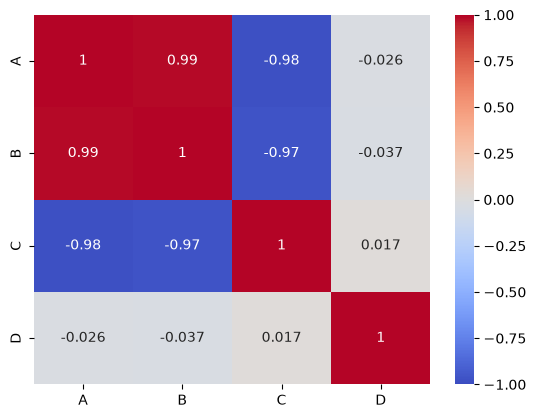

In [3]:
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.show()

## ノイズの大きさを変えると相関係数はどう変わるか

Aに対する係数(2倍)は固定したまま、ノイズだけを大きくしていく。
係数が同じでもノイズが相対的に大きくなるほど相関は弱まるはず。

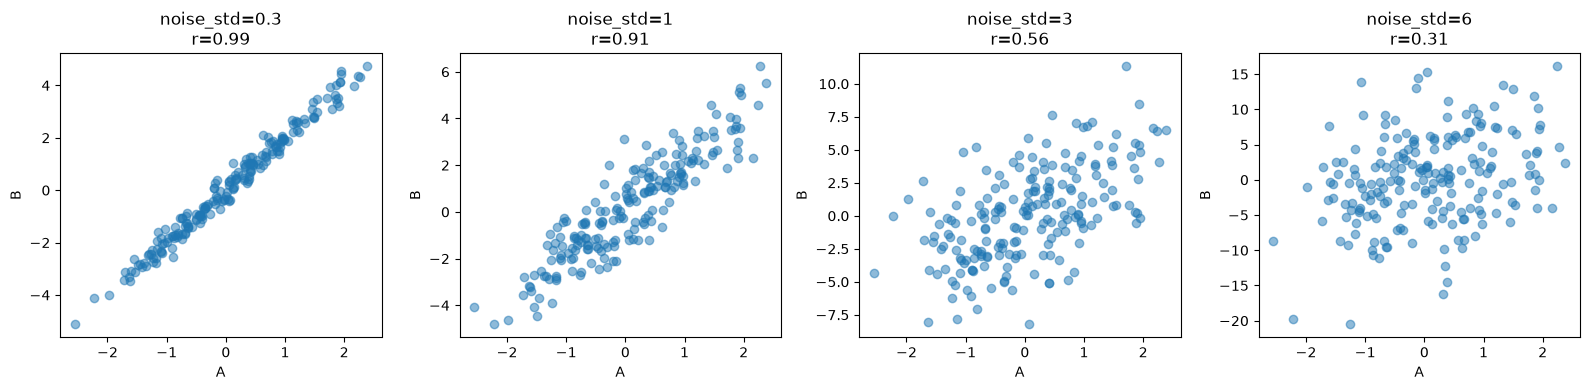

In [4]:
noise_levels = [0.3, 1, 3, 6]

fig, axes = plt.subplots(1, len(noise_levels), figsize=(16, 4))

for ax, noise_std in zip(axes, noise_levels):
    B_test = A * 2 + np.random.normal(0, noise_std, n)
    r = np.corrcoef(A, B_test)[0, 1]
    ax.scatter(A, B_test, alpha=0.5)
    ax.set_title(f"noise_std={noise_std}\nr={r:.2f}")
    ax.set_xlabel("A")
    ax.set_ylabel("B")

plt.tight_layout()
plt.show()